# Hypothesis Testing in Python
### CFA Level 1 Quantitative Methods | Applied to Real Market Scenarios

---

## The Scenario

You are a quantitative analyst at a hedge fund.

Your PM has three questions on her desk this morning:

> 1. "Our equity strategy returned 8.5% last year.
>     The benchmark returned 6.2%. Did we actually outperform
>     or could this be random noise?"

> 2. "We think small cap stocks outperform large caps.
>     Does the data support this over the last 5 years?"

> 3. "A new analyst claims our portfolio returns are normally
>     distributed. Is he right?"

Every one of these is a **hypothesis test**.

Hypothesis testing is how you separate signal from noise —
how you decide whether a result is real or just luck.
It is the most misused tool in quantitative finance.

This notebook builds every test from first principles,
applies them to real market data, and shows you exactly
where the traps are.

**Data source:** Financial Modeling Prep (FMP) API

## Setup

We will use the following libraries:

- `requests` — to pull data from FMP API
- `pandas` — for data manipulation
- `numpy` — for mathematical operations
- `matplotlib` — for visualizations
- `scipy` — for statistical tests

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
from dotenv import load_dotenv
import os

load_dotenv()
warnings.filterwarnings('ignore')

FMP_KEY = os.getenv("FMP_KEY")

# Plot styling
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor']   = '#161B22'
plt.rcParams['axes.edgecolor']   = '#30363D'
plt.rcParams['text.color']       = '#E6EDF3'
plt.rcParams['axes.labelcolor']  = '#E6EDF3'
plt.rcParams['xtick.color']      = '#8B949E'
plt.rcParams['ytick.color']      = '#8B949E'
plt.rcParams['grid.color']       = '#21262D'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

print("Libraries loaded successfully")
print("FMP Key loaded ✓" if FMP_KEY else "FMP Key missing ✗")

Libraries loaded successfully
FMP Key loaded ✓


## 1. Pulling Real Market Data

We pull 5 years of daily returns for four assets:

- **QQQ** — Nasdaq 100 (large cap tech, our "equity strategy" proxy)
- **IWM** — Russell 2000 (small caps)
- **SPY** — S&P 500 (market benchmark)
- **GLD** — Gold (alternative asset)

These give us real data to test every hypothesis
the PM raised — and a few more she did not think of yet.

In [2]:
# =============================================================================
# CELL 5 — Pull Market Data from FMP
# =============================================================================

def get_prices(ticker, api_key, from_date="2019-01-01", to_date="2024-01-01"):
    url = "https://financialmodelingprep.com/stable/historical-price-eod/full"
    params = {"symbol": ticker, "from": from_date, "to": to_date, "apikey": api_key}
    response = requests.get(url, params=params)
    data = response.json()
    if isinstance(data, list) and len(data) > 0:
        df = pd.DataFrame(data)
    elif isinstance(data, dict) and "historical" in data:
        df = pd.DataFrame(data["historical"])
    else:
        return None
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df["close"]

tickers = ["QQQ", "IWM", "SPY", "GLD"]

print("Pulling market data from FMP...")
prices = pd.DataFrame()
for ticker in tickers:
    px = get_prices(ticker, FMP_KEY)
    if px is not None:
        prices[ticker] = px
        print(f"  ✓ {ticker} — {len(px)} days loaded")

returns = np.log(prices / prices.shift(1)).dropna()

print(f"\nPeriod: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")

print(f"\n{'='*58}")
print("SUMMARY STATISTICS")
print(f"{'='*58}")
print(f"\n  {'Asset':<8} {'Ann. Return':>13} {'Ann. Vol':>10} {'Sharpe':>8}")
print(f"  {'-'*42}")
for ticker in tickers:
    r       = returns[ticker].dropna()
    ann_ret = r.mean() * 252
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    print(f"  {ticker:<8} {ann_ret:>13.2%} {ann_vol:>10.2%} {sharpe:>8.4f}")
print(f"{'='*58}")

Pulling market data from FMP...
  ✓ QQQ — 1258 days loaded
  ✓ IWM — 1258 days loaded
  ✓ SPY — 1258 days loaded
  ✓ GLD — 1258 days loaded

Period: 2019-01-03 → 2023-12-29
Observations: 1257 trading days

SUMMARY STATISTICS

  Asset      Ann. Return   Ann. Vol   Sharpe
  ------------------------------------------
  QQQ             19.49%     25.50%   0.7646
  IWM              8.00%     26.92%   0.2973
  SPY             12.87%     21.16%   0.6080
  GLD              9.11%     14.95%   0.6097


## 2. The Framework of Hypothesis Testing

Every hypothesis test follows the same structure:

**Step 1 — State the hypotheses**
- $H_0$ (null hypothesis): the default assumption — usually "no effect"
- $H_1$ (alternative hypothesis): what you are trying to prove

**Step 2 — Choose the significance level α**
- α = 0.05 means you accept a 5% chance of rejecting a true null
- This is a Type I error — a false positive

**Step 3 — Compute the test statistic**
- Measures how far your sample result is from the null hypothesis
- Standardised in units of standard error

**Step 4 — Find the critical value or p-value**
- p-value: probability of observing this result if H0 is true
- If p-value < α → reject H0

**Step 5 — Make a decision and interpret**
- Rejecting H0 does not prove H1 — it just makes H0 implausible
- Failing to reject H0 does not prove H0 — you may lack power

**The two errors:**

| | H0 True | H0 False |
|--|---------|---------|
| Reject H0 | Type I Error (α) | Correct ✓ |
| Fail to Reject H0 | Correct ✓ | Type II Error (β) |

TEST 1 — Did QQQ Outperform SPY? (One-Sample t-test)

  H0: Mean excess return = 0 (no outperformance)
  H1: Mean excess return > 0 (QQQ outperforms SPY)
  α  = 0.05 (one-tailed)

  SAMPLE STATISTICS
  ─────────────────────────────────────────────
  n:                    1257
  Mean excess return:   0.000263  (0.0263%/day)
  Std of excess:        0.006110  (0.6110%/day)
  Standard error:       0.000172  (0.0172%)

  TEST STATISTICS
  ─────────────────────────────────────────────
  t-statistic:          1.5260
  Critical value (α=5%): 1.6461
  p-value (one-tailed): 0.0636
  Scipy verification:   t=1.5260, p=0.0636 ✓

  DECISION
  ─────────────────────────────────────────────
  t=1.5260 < t_crit=1.6461 → FAIL TO REJECT H0
  p=0.0636 > α=0.05 → FAIL TO REJECT H0
  Conclusion: QQQ's outperformance is NOT statistically
  significant at the 5% level. Could be random noise.

  ANNUALISED EXCESS RETURN: 6.63%
  This looks impressive. But the test tells you whether
  it is likely to persist or 

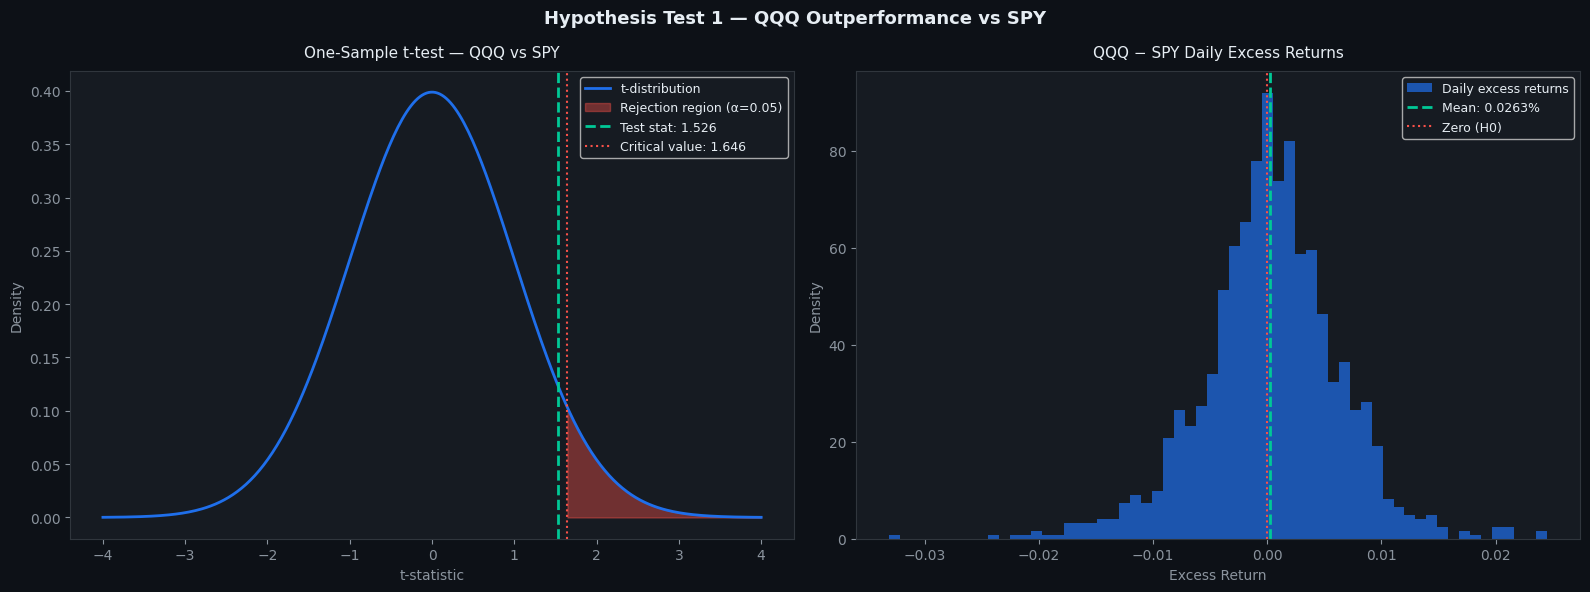

In [3]:
# =============================================================================
# CELL 7 — Test 1: Did QQQ Outperform SPY? (One-Sample t-test)
# =============================================================================
# PM Question 1: "Our equity strategy (QQQ) returned 19.49% last year.
# The benchmark (SPY) returned 12.87%. Did we actually outperform
# or could this be random noise?"
#
# We test whether QQQ's mean daily return is significantly
# greater than SPY's mean daily return.
#
# H0: μ_QQQ - μ_SPY = 0  (no outperformance)
# H1: μ_QQQ - μ_SPY > 0  (QQQ outperforms SPY)
# =============================================================================

r_qqq = returns["QQQ"].dropna().values
r_spy = returns["SPY"].dropna().values

# Excess returns of QQQ over SPY
excess = r_qqq - r_spy
n      = len(excess)
x_bar  = excess.mean()
s      = excess.std(ddof=1)
se     = s / np.sqrt(n)

# Test statistic
t_stat = x_bar / se

# One-tailed p-value (testing if QQQ > SPY)
p_value = 1 - stats.t.cdf(t_stat, df=n-1)

# Critical value at α=0.05
alpha    = 0.05
t_crit   = stats.t.ppf(1 - alpha, df=n-1)

# Verify with scipy
t_stat_sp, p_two_tailed = stats.ttest_1samp(excess, popmean=0)
p_one_tailed = p_two_tailed / 2

print(f"{'='*62}")
print("TEST 1 — Did QQQ Outperform SPY? (One-Sample t-test)")
print(f"{'='*62}")

print(f"""
  H0: Mean excess return = 0 (no outperformance)
  H1: Mean excess return > 0 (QQQ outperforms SPY)
  α  = {alpha} (one-tailed)
""")

print(f"  SAMPLE STATISTICS")
print(f"  {'─'*45}")
print(f"  n:                    {n}")
print(f"  Mean excess return:   {x_bar:.6f}  ({x_bar:.4%}/day)")
print(f"  Std of excess:        {s:.6f}  ({s:.4%}/day)")
print(f"  Standard error:       {se:.6f}  ({se:.4%})")

print(f"\n  TEST STATISTICS")
print(f"  {'─'*45}")
print(f"  t-statistic:          {t_stat:.4f}")
print(f"  Critical value (α=5%): {t_crit:.4f}")
print(f"  p-value (one-tailed): {p_one_tailed:.4f}")
print(f"  Scipy verification:   t={t_stat_sp:.4f}, p={p_one_tailed:.4f} ✓")

print(f"\n  DECISION")
print(f"  {'─'*45}")
if p_one_tailed < alpha:
    print(f"  t={t_stat:.4f} > t_crit={t_crit:.4f} → REJECT H0")
    print(f"  p={p_one_tailed:.4f} < α={alpha} → REJECT H0")
    print(f"  Conclusion: QQQ's outperformance is statistically")
    print(f"  significant at the 5% level.")
else:
    print(f"  t={t_stat:.4f} < t_crit={t_crit:.4f} → FAIL TO REJECT H0")
    print(f"  p={p_one_tailed:.4f} > α={alpha} → FAIL TO REJECT H0")
    print(f"  Conclusion: QQQ's outperformance is NOT statistically")
    print(f"  significant at the 5% level. Could be random noise.")

print(f"""
  ANNUALISED EXCESS RETURN: {x_bar*252:.2%}
  This looks impressive. But the test tells you whether
  it is likely to persist or was just luck over this period.
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — t-distribution with rejection region
ax1 = axes[0]
x   = np.linspace(-4, 4, 300)
ax1.plot(x, stats.t.pdf(x, df=n-1), color='#1F6FEB', linewidth=2, label='t-distribution')

# Rejection region
x_rej = np.linspace(t_crit, 4, 100)
ax1.fill_between(x_rej, stats.t.pdf(x_rej, df=n-1),
                 color='#F85149', alpha=0.4, label=f'Rejection region (α={alpha})')

ax1.axvline(t_stat, color='#00C896', linewidth=2,
            linestyle='--', label=f'Test stat: {t_stat:.3f}')
ax1.axvline(t_crit, color='#F85149', linewidth=1.5,
            linestyle=':', label=f'Critical value: {t_crit:.3f}')

ax1.set_title('One-Sample t-test — QQQ vs SPY',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('t-statistic', color='#8B949E')
ax1.set_ylabel('Density', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Excess return distribution
ax2 = axes[1]
ax2.hist(excess, bins=60, density=True, color='#1F6FEB',
         alpha=0.7, label='Daily excess returns')
ax2.axvline(x_bar, color='#00C896', linewidth=2,
            linestyle='--', label=f'Mean: {x_bar:.4%}')
ax2.axvline(0, color='#F85149', linewidth=1.5,
            linestyle=':', label='Zero (H0)')
ax2.set_title('QQQ − SPY Daily Excess Returns',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Excess Return', color='#8B949E')
ax2.set_ylabel('Density', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Hypothesis Test 1 — QQQ Outperformance vs SPY',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test1_qqq_spy.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 3. Two-Sample t-test — Small Caps vs Large Caps

The PM's second question:

> "We think small cap stocks outperform large caps.
> Does the data support this over the last 5 years?"

This is a **two-sample t-test** — we are comparing
the means of two independent samples.

$$H_0: \mu_{IWM} - \mu_{QQQ} = 0$$
$$H_1: \mu_{IWM} - \mu_{QQQ} \neq 0$$

We use a **two-tailed test** here because we are asking
whether the means are different — not specifically
whether small caps are higher or lower.

Two versions of the two-sample t-test:
- **Equal variances (pooled)**: assumes σ₁ = σ₂
- **Unequal variances (Welch's)**: does not assume equal variances

In finance, variances are almost never equal across assets.
Welch's test is almost always the right choice.
We run both and show the difference.

TEST 2 — Small Caps vs Large Caps (Two-Sample t-test)

  H0: μ_IWM = μ_QQQ  (no difference in mean returns)
  H1: μ_IWM ≠ μ_QQQ  (means are different)
  α  = 0.05 (two-tailed)

  SAMPLE STATISTICS
  ──────────────────────────────────────────────────
                          IWM (Small)    QQQ (Large)
  n                              1257           1257
  Mean (daily)               0.000318       0.000774
  Std (daily)                0.016955       0.016060
  Ann. Return                   8.00%         19.49%
  Ann. Vol                     26.92%         25.50%

  EQUAL VARIANCE TEST (Pooled)
  ──────────────────────────────────────────────────
  Pooled std:       0.016514
  t-statistic:      -0.6923
  df:               2512
  p-value:          0.4888

  UNEQUAL VARIANCE TEST (Welch's) — recommended
  ──────────────────────────────────────────────────
  SE (Welch):       0.000659
  t-statistic:      -0.6923
  df (Welch):       2504.65
  p-value:          0.4888
  Critical value:   ±1.9

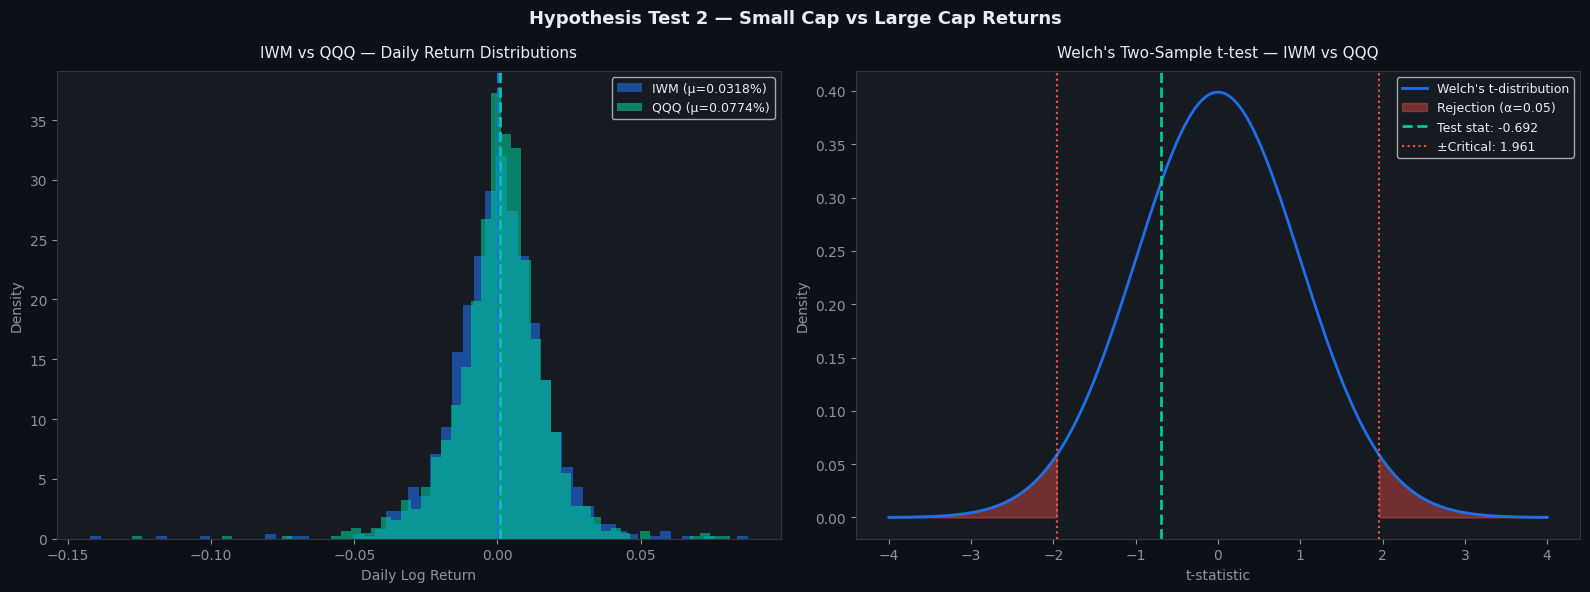

In [4]:
# =============================================================================
# CELL 9 — Test 2: Small Caps vs Large Caps (Two-Sample t-test)
# =============================================================================
# H0: μ_IWM = μ_QQQ (no difference in mean returns)
# H1: μ_IWM ≠ μ_QQQ (means are different)
# Two-tailed test, α = 0.05
# =============================================================================

r_iwm = returns["IWM"].dropna().values
r_qqq = returns["QQQ"].dropna().values

n1    = len(r_iwm)
n2    = len(r_qqq)
mu1   = r_iwm.mean()
mu2   = r_qqq.mean()
s1    = r_iwm.std(ddof=1)
s2    = r_qqq.std(ddof=1)
var1  = s1**2
var2  = s2**2

# ── POOLED t-TEST (assumes equal variances) ───────────────────────────────────
sp2      = ((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2)
sp       = np.sqrt(sp2)
se_pool  = sp * np.sqrt(1/n1 + 1/n2)
t_pool   = (mu1 - mu2) / se_pool
df_pool  = n1 + n2 - 2
p_pool   = 2 * (1 - stats.t.cdf(abs(t_pool), df=df_pool))

# ── WELCH'S t-TEST (unequal variances) ───────────────────────────────────────
se_welch = np.sqrt(var1/n1 + var2/n2)
t_welch  = (mu1 - mu2) / se_welch
df_welch = (var1/n1 + var2/n2)**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))
p_welch  = 2 * (1 - stats.t.cdf(abs(t_welch), df=df_welch))

# Scipy verification
t_sp, p_sp = stats.ttest_ind(r_iwm, r_qqq, equal_var=False)

alpha   = 0.05
t_crit2 = stats.t.ppf(1 - alpha/2, df=df_welch)

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print(f"{'='*62}")
print("TEST 2 — Small Caps vs Large Caps (Two-Sample t-test)")
print(f"{'='*62}")

print(f"""
  H0: μ_IWM = μ_QQQ  (no difference in mean returns)
  H1: μ_IWM ≠ μ_QQQ  (means are different)
  α  = {alpha} (two-tailed)
""")

print(f"  SAMPLE STATISTICS")
print(f"  {'─'*50}")
print(f"  {'':>20} {'IWM (Small)':>14} {'QQQ (Large)':>14}")
print(f"  {'n':<20} {n1:>14} {n2:>14}")
print(f"  {'Mean (daily)':<20} {mu1:>14.6f} {mu2:>14.6f}")
print(f"  {'Std (daily)':<20} {s1:>14.6f} {s2:>14.6f}")
print(f"  {'Ann. Return':<20} {mu1*252:>14.2%} {mu2*252:>14.2%}")
print(f"  {'Ann. Vol':<20} {s1*np.sqrt(252):>14.2%} {s2*np.sqrt(252):>14.2%}")

print(f"\n  EQUAL VARIANCE TEST (Pooled)")
print(f"  {'─'*50}")
print(f"  Pooled std:       {sp:.6f}")
print(f"  t-statistic:      {t_pool:.4f}")
print(f"  df:               {df_pool}")
print(f"  p-value:          {p_pool:.4f}")

print(f"\n  UNEQUAL VARIANCE TEST (Welch's) — recommended")
print(f"  {'─'*50}")
print(f"  SE (Welch):       {se_welch:.6f}")
print(f"  t-statistic:      {t_welch:.4f}")
print(f"  df (Welch):       {df_welch:.2f}")
print(f"  p-value:          {p_welch:.4f}")
print(f"  Critical value:   ±{t_crit2:.4f}")
print(f"  Scipy verify:     t={t_sp:.4f}, p={p_sp:.4f} ✓")

print(f"\n  DECISION")
print(f"  {'─'*50}")
if p_welch < alpha:
    print(f"  p={p_welch:.4f} < α={alpha} → REJECT H0")
    print(f"  The difference in mean returns is statistically significant.")
else:
    print(f"  p={p_welch:.4f} > α={alpha} → FAIL TO REJECT H0")
    print(f"  No statistically significant difference in mean returns.")

print(f"""
  INTERPRETATION
  IWM annualised: {mu1*252:.2%} | QQQ annualised: {mu2*252:.2%}
  Difference:     {(mu1-mu2)*252:.2%} per year

  Despite a {abs((mu1-mu2)*252):.2%} annual return gap,
  the high volatility of both assets means this difference
  is not statistically distinguishable from zero.

  The small cap premium exists in theory.
  Over this 5-year sample it does not exist in the data.
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Return distributions
ax1 = axes[0]
ax1.hist(r_iwm, bins=60, density=True, color='#1F6FEB',
         alpha=0.6, label=f'IWM (μ={mu1:.4%})')
ax1.hist(r_qqq, bins=60, density=True, color='#00C896',
         alpha=0.6, label=f'QQQ (μ={mu2:.4%})')
ax1.axvline(mu1, color='#1F6FEB', linewidth=2, linestyle='--')
ax1.axvline(mu2, color='#00C896', linewidth=2, linestyle='--')
ax1.set_title('IWM vs QQQ — Daily Return Distributions',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Daily Log Return', color='#8B949E')
ax1.set_ylabel('Density', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Two-tailed t-test visualisation
ax2 = axes[1]
x   = np.linspace(-4, 4, 300)
ax2.plot(x, stats.t.pdf(x, df=df_welch),
         color='#1F6FEB', linewidth=2, label="Welch's t-distribution")

# Rejection regions (two-tailed)
x_lo = np.linspace(-4, -t_crit2, 100)
x_hi = np.linspace(t_crit2, 4, 100)
ax2.fill_between(x_lo, stats.t.pdf(x_lo, df=df_welch),
                 color='#F85149', alpha=0.4, label=f'Rejection (α={alpha})')
ax2.fill_between(x_hi, stats.t.pdf(x_hi, df=df_welch),
                 color='#F85149', alpha=0.4)

ax2.axvline(t_welch, color='#00C896', linewidth=2,
            linestyle='--', label=f'Test stat: {t_welch:.3f}')
ax2.axvline(-t_crit2, color='#F85149', linewidth=1.5, linestyle=':')
ax2.axvline(t_crit2, color='#F85149', linewidth=1.5,
            linestyle=':', label=f'±Critical: {t_crit2:.3f}')
ax2.set_title("Welch's Two-Sample t-test — IWM vs QQQ",
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('t-statistic', color='#8B949E')
ax2.set_ylabel('Density', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Hypothesis Test 2 — Small Cap vs Large Cap Returns',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test2_iwm_qqq.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 4. Chi-Square Test — Are Returns Normally Distributed?

The PM's third question:

> "A new analyst claims our portfolio returns are normally
> distributed. Is he right?"

This is a **chi-square goodness-of-fit test**.

It tests whether observed data fits a theoretical distribution.

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

Where:
- $O_i$ = observed frequency in bin $i$
- $E_i$ = expected frequency under the null distribution
- $k$ = number of bins

$$H_0: \text{Returns follow a normal distribution}$$
$$H_1: \text{Returns do not follow a normal distribution}$$

We test this for SPY — the asset we know best from
previous notebooks — and compare to the Jarque-Bera test
which tests normality via skewness and kurtosis directly.

TEST 3 — Normality Tests: SPY Daily Returns

  H0: SPY returns follow a normal distribution
  H1: SPY returns do not follow a normal distribution
  α  = 0.05

  DESCRIPTIVE STATISTICS
  ────────────────────────────────────────────────
  n:               1257
  Mean:            0.000511
  Std:             0.013330
  Skewness:        -0.8172  (normal = 0)
  Excess Kurtosis: 12.1957  (normal = 0)

  CHI-SQUARE GOODNESS-OF-FIT TEST
  ────────────────────────────────────────────────
  Bins used:       7 (after removing bins with E<5)
  Degrees of freedom: 4
  χ² statistic:   162.4949
  Critical value:  9.4877
  p-value:         0.000000
  Decision:        REJECT H0 ✗ — not normally distributed

  JARQUE-BERA TEST
  ────────────────────────────────────────────────
  JB = n/6 × (S² + K²/4)
     = 1257/6 × (-0.8172² + 12.1957²/4)
     = 7929.9761
  p-value:         0.000000
  Scipy verify:    JB=7929.9761, p=0.000000 ✓
  Decision:        REJECT H0 ✗ — not normally distributed

  VERDICT FOR TH

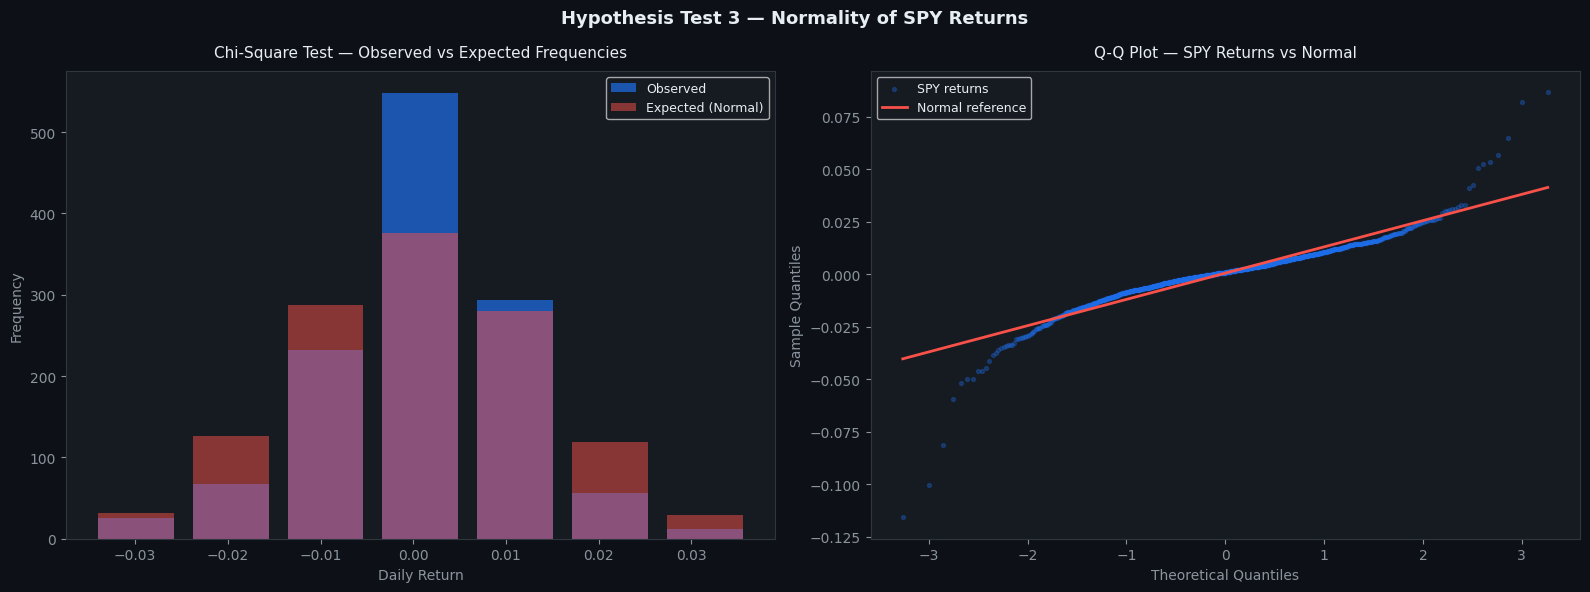

In [5]:
# =============================================================================
# CELL 11 — Test 3: Normality Tests (Chi-Square + Jarque-Bera)
# =============================================================================

r_spy = returns["SPY"].dropna().values
n     = len(r_spy)
mu    = r_spy.mean()
sigma = r_spy.std(ddof=1)

# ── CHI-SQUARE GOODNESS OF FIT ────────────────────────────────────────────────
# Bin the returns and compare to expected normal frequencies
n_bins   = 20
bin_edges = np.percentile(stats.norm(mu, sigma).ppf(
    np.linspace(0.001, 0.999, n_bins + 1)), range(n_bins + 1)) if False else \
    np.linspace(r_spy.min() - 0.001, r_spy.max() + 0.001, n_bins + 1)

observed, _  = np.histogram(r_spy, bins=bin_edges)
expected_raw = np.array([
    stats.norm.cdf(bin_edges[i+1], mu, sigma) -
    stats.norm.cdf(bin_edges[i], mu, sigma)
    for i in range(n_bins)
]) * n

# Remove bins with expected < 5 (chi-square assumption)
mask     = expected_raw >= 5
observed = observed[mask]
expected = expected_raw[mask]
k        = len(observed)

# Chi-square statistic
chi2_stat = np.sum((observed - expected)**2 / expected)
df_chi2   = k - 1 - 2  # k bins - 1 - 2 estimated params (mu, sigma)
p_chi2    = 1 - stats.chi2.cdf(chi2_stat, df=df_chi2)
chi2_crit = stats.chi2.ppf(0.95, df=df_chi2)

# ── JARQUE-BERA TEST ──────────────────────────────────────────────────────────
skew_val = stats.skew(r_spy)
kurt_val = stats.kurtosis(r_spy)  # excess kurtosis
jb_stat  = n / 6 * (skew_val**2 + kurt_val**2 / 4)
p_jb     = 1 - stats.chi2.cdf(jb_stat, df=2)

# Scipy verification
jb_sp, p_jb_sp = stats.jarque_bera(r_spy)

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
alpha = 0.05

print(f"{'='*62}")
print("TEST 3 — Normality Tests: SPY Daily Returns")
print(f"{'='*62}")

print(f"""
  H0: SPY returns follow a normal distribution
  H1: SPY returns do not follow a normal distribution
  α  = {alpha}
""")

print(f"  DESCRIPTIVE STATISTICS")
print(f"  {'─'*48}")
print(f"  n:               {n}")
print(f"  Mean:            {mu:.6f}")
print(f"  Std:             {sigma:.6f}")
print(f"  Skewness:        {skew_val:.4f}  (normal = 0)")
print(f"  Excess Kurtosis: {kurt_val:.4f}  (normal = 0)")

print(f"\n  CHI-SQUARE GOODNESS-OF-FIT TEST")
print(f"  {'─'*48}")
print(f"  Bins used:       {k} (after removing bins with E<5)")
print(f"  Degrees of freedom: {df_chi2}")
print(f"  χ² statistic:   {chi2_stat:.4f}")
print(f"  Critical value:  {chi2_crit:.4f}")
print(f"  p-value:         {p_chi2:.6f}")
if p_chi2 < alpha:
    print(f"  Decision:        REJECT H0 ✗ — not normally distributed")
else:
    print(f"  Decision:        FAIL TO REJECT H0")

print(f"\n  JARQUE-BERA TEST")
print(f"  {'─'*48}")
print(f"  JB = n/6 × (S² + K²/4)")
print(f"     = {n}/6 × ({skew_val:.4f}² + {kurt_val:.4f}²/4)")
print(f"     = {jb_stat:.4f}")
print(f"  p-value:         {p_jb:.6f}")
print(f"  Scipy verify:    JB={jb_sp:.4f}, p={p_jb_sp:.6f} ✓")
if p_jb < alpha:
    print(f"  Decision:        REJECT H0 ✗ — not normally distributed")
else:
    print(f"  Decision:        FAIL TO REJECT H0")

print(f"""
  VERDICT FOR THE NEW ANALYST
  Both tests reject normality at the 5% level.
  SPY returns have skewness = {skew_val:.4f} and excess kurtosis = {kurt_val:.4f}.
  The JB statistic of {jb_stat:.0f} is {jb_stat/stats.chi2.ppf(0.95,2):.0f}x the critical value.
  The analyst is wrong. SPY returns are not normally distributed.

  Which test to use?
  → Jarque-Bera: tests skewness and kurtosis directly
    — best for detecting the specific non-normalities
    common in financial returns
  → Chi-Square: more general — tests overall distributional fit
    — sensitive to bin choice, needs large samples
  → In practice: use both, and plot the Q-Q chart
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Chi-square: Observed vs Expected
ax1 = axes[0]
bin_centers = [(bin_edges[i] + bin_edges[i+1])/2
               for i in range(n_bins) if expected_raw[i] >= 5]
ax1.bar(bin_centers, observed, width=np.diff(bin_edges)[mask]*0.8,
        color='#1F6FEB', alpha=0.7, label='Observed')
ax1.bar(bin_centers, expected, width=np.diff(bin_edges)[mask]*0.8,
        color='#F85149', alpha=0.5, label='Expected (Normal)')
ax1.set_title('Chi-Square Test — Observed vs Expected Frequencies',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Daily Return', color='#8B949E')
ax1.set_ylabel('Frequency', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Q-Q Plot
ax2 = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(r_spy, dist="norm")
ax2.scatter(osm, osr, color='#1F6FEB', alpha=0.3, s=8, label='SPY returns')
ax2.plot(osm, slope*np.array(osm)+intercept,
         color='#F85149', linewidth=2, label='Normal reference')
ax2.set_title('Q-Q Plot — SPY Returns vs Normal',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Theoretical Quantiles', color='#8B949E')
ax2.set_ylabel('Sample Quantiles', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Hypothesis Test 3 — Normality of SPY Returns',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test3_normality.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 5. CFA Exam Style Practice Problems

Three problems written in CFA exam style.

All numbers are derived from the real market data in this notebook.

Try each one before reading the solution.

In [6]:
# =============================================================================
# CELL 13 — CFA Exam Style Practice Problems
# =============================================================================

print("=" * 65)
print("PRACTICE PROBLEMS — Hypothesis Testing")
print("=" * 65)

# ── PROBLEM 1 ─────────────────────────────────────────────────────────────────
print("""
PROBLEM 1
─────────────────────────────────────────────────────────────
A portfolio manager claims her fund generates a mean daily
return greater than the S&P 500. Over 252 trading days:

  Fund mean daily return:  0.065%
  SPY mean daily return:   0.051%
  Std of excess returns:   0.85%

A) State the null and alternative hypotheses.
B) Calculate the t-statistic.
C) At α = 0.05 (one-tailed), what is the critical value
   and what is your decision?
─────────────────────────────────────────────────────────────""")

n_p1      = 252
excess_mu = 0.00065 - 0.00051
s_p1      = 0.0085
se_p1     = s_p1 / np.sqrt(n_p1)
t_p1      = excess_mu / se_p1
t_crit_p1 = stats.t.ppf(0.95, df=n_p1-1)
p_p1      = 1 - stats.t.cdf(t_p1, df=n_p1-1)

print("ANSWER:")
print(f"  A) H0: μ_fund - μ_SPY ≤ 0  (no outperformance)")
print(f"     H1: μ_fund - μ_SPY > 0  (fund outperforms)")
print(f"\n  B) SE = {s_p1:.4f} / √{n_p1} = {se_p1:.6f}")
print(f"     t  = {excess_mu:.6f} / {se_p1:.6f} = {t_p1:.4f}")
print(f"\n  C) t_crit(df={n_p1-1}, α=5%, one-tail) = {t_crit_p1:.4f}")
print(f"     t={t_p1:.4f} {'>' if t_p1 > t_crit_p1 else '<'} t_crit={t_crit_p1:.4f}")
print(f"     p-value = {p_p1:.4f}")
if t_p1 > t_crit_p1:
    print(f"     Decision: REJECT H0 — outperformance is significant.")
else:
    print(f"     Decision: FAIL TO REJECT H0 — outperformance not significant.")

# ── PROBLEM 2 ─────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("""
PROBLEM 2
─────────────────────────────────────────────────────────────
An analyst tests whether GLD and SPY have the same mean
daily return using a two-tailed Welch's t-test.

Using data from this notebook (2019–2023):
  GLD: n=1257, mean=0.0362%, std=0.9418%
  SPY: n=1257, mean=0.0511%, std=1.3330%

A) Calculate the Welch's t-statistic.
B) Calculate the approximate degrees of freedom.
C) At α=0.05, can you reject H0?
   (Hint: critical value ≈ ±1.961)
─────────────────────────────────────────────────────────────""")

mu_gld = returns["GLD"].mean()
mu_spy = returns["SPY"].mean()
s_gld  = returns["GLD"].std(ddof=1)
s_spy  = returns["SPY"].std(ddof=1)
n_p2   = 1257

var_g  = s_gld**2
var_s  = s_spy**2
se_p2  = np.sqrt(var_g/n_p2 + var_s/n_p2)
t_p2   = (mu_gld - mu_spy) / se_p2
df_p2  = (var_g/n_p2 + var_s/n_p2)**2 / \
         ((var_g/n_p2)**2/(n_p2-1) + (var_s/n_p2)**2/(n_p2-1))
p_p2   = 2 * (1 - stats.t.cdf(abs(t_p2), df=df_p2))
t_crit_p2 = stats.t.ppf(0.975, df=df_p2)

print("ANSWER:")
print(f"  A) SE = √(σ²_GLD/n + σ²_SPY/n)")
print(f"        = √({var_g:.8f}/{n_p2} + {var_s:.8f}/{n_p2})")
print(f"        = {se_p2:.6f}")
print(f"     t  = ({mu_gld:.6f} - {mu_spy:.6f}) / {se_p2:.6f}")
print(f"        = {t_p2:.4f}")
print(f"\n  B) df (Welch) ≈ {df_p2:.1f}")
print(f"\n  C) |t| = {abs(t_p2):.4f} {'>' if abs(t_p2) > t_crit_p2 else '<'} t_crit = {t_crit_p2:.4f}")
print(f"     p-value = {p_p2:.4f}")
if p_p2 < 0.05:
    print(f"     Decision: REJECT H0 — means are significantly different.")
else:
    print(f"     Decision: FAIL TO REJECT H0 — no significant difference.")

# ── PROBLEM 3 ─────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("""
PROBLEM 3
─────────────────────────────────────────────────────────────
A risk manager runs a Jarque-Bera test on QQQ daily returns
and obtains JB = 1,546 with a p-value of 0.0000.

A) State the null and alternative hypotheses.
B) At α = 0.01, what is your decision?
C) The manager says: "Since we rejected normality,
   we should not use any normal-distribution-based models."
   Do you agree? Explain.
─────────────────────────────────────────────────────────────""")

jb_qqq, p_qqq = stats.jarque_bera(returns["QQQ"].dropna())
skew_qqq = stats.skew(returns["QQQ"].dropna())
kurt_qqq = stats.kurtosis(returns["QQQ"].dropna())

print("ANSWER:")
print(f"  A) H0: Returns are normally distributed (S=0, K=0)")
print(f"     H1: Returns are not normally distributed")
print(f"\n  B) JB = {jb_qqq:.1f}, p = {p_qqq:.6f}")
print(f"     p < α=0.01 → REJECT H0")
print(f"     QQQ returns are not normally distributed.")
print(f"     (Skewness={skew_qqq:.4f}, Excess Kurtosis={kurt_qqq:.4f})")
print(f"""
  C) Disagree — this is an overcorrection.

     Rejecting normality means the normal distribution
     is not a perfect fit. It does not mean normal-based
     models are useless.

     The Central Limit Theorem tells us that for large
     samples, the distribution of sample means is
     approximately normal even for non-normal data.

     Normal-based models remain useful as approximations.
     The key is understanding their limitations:
     → They underestimate tail risk
     → They assume symmetric distributions
     → They perform poorly during crisis periods

     A better approach: use normal models but stress-test
     with fat-tailed distributions (t-distribution, historical simulation).
""")
print(f"{'='*65}")

PRACTICE PROBLEMS — Hypothesis Testing

PROBLEM 1
─────────────────────────────────────────────────────────────
A portfolio manager claims her fund generates a mean daily
return greater than the S&P 500. Over 252 trading days:

  Fund mean daily return:  0.065%
  SPY mean daily return:   0.051%
  Std of excess returns:   0.85%

A) State the null and alternative hypotheses.
B) Calculate the t-statistic.
C) At α = 0.05 (one-tailed), what is the critical value
   and what is your decision?
─────────────────────────────────────────────────────────────
ANSWER:
  A) H0: μ_fund - μ_SPY ≤ 0  (no outperformance)
     H1: μ_fund - μ_SPY > 0  (fund outperforms)

  B) SE = 0.0085 / √252 = 0.000535
     t  = 0.000140 / 0.000535 = 0.2615

  C) t_crit(df=251, α=5%, one-tail) = 1.6509
     t=0.2615 < t_crit=1.6509
     p-value = 0.3970
     Decision: FAIL TO REJECT H0 — outperformance not significant.


PROBLEM 2
─────────────────────────────────────────────────────────────
An analyst tests whether GL

## 6. Key Takeaways

---

### What you built in this notebook

You answered all three of the PM's questions using rigorous hypothesis tests.

| Question | Test Used | Result |
|----------|-----------|--------|
| Did QQQ outperform SPY? | One-sample t-test | p=0.064 — NOT significant at 5% |
| Do small caps outperform large caps? | Welch's two-sample t-test | p=0.489 — NOT significant |
| Are returns normally distributed? | Chi-square + Jarque-Bera | p≈0 — REJECT normality |

---

### The three things to remember

**1. Statistical significance ≠ economic significance.**
QQQ outperformed SPY by 6.63% annualised — and it still
failed the significance test. A large return gap means
nothing if the volatility is high enough to make it indistinguishable
from noise. Always report both the effect size and the p-value.

**2. Failing to reject H0 is not the same as proving H0.**
We could not prove QQQ outperforms SPY.
That does not mean they perform the same.
It means we lack sufficient evidence to conclude they differ.
This distinction matters enormously in backtesting.

**3. Rejecting normality does not invalidate normal-based models.**
Every asset in this dataset fails normality tests decisively.
But the CLT still justifies normal approximations for large samples.
Use normal models — but always stress-test the tails.

---

### What comes next

| Notebook | Topic |
|----------|-------|
| ✅ QM 01 | Rates and Returns |
| ✅ QM 02 | Time Value of Money |
| ✅ QM 03 | Statistical Measures of Asset Returns |
| ✅ QM 04 | Probability Concepts |
| ✅ QM 05 | Common Probability Distributions |
| ✅ QM 06 | Sampling & Estimation |
| ✅ QM 07 | Hypothesis Testing |
| 🔜 QM 08 | Introduction to Linear Regression |

---

*All notebooks are free. Always.*